# Smart Home Energy Usage Consumption Prediction

## Round 1 Analytics Assessment

### Objective

Develop machine learning models to predict:

- **Appliances** energy consumption
- **Lights** energy consumption

using indoor environmental conditions, outdoor weather variables, and engineered temporal features.

### Approach

This analysis covers:

1. Data quality and consistency assessment
2. Exploratory analysis of energy consumption patterns
3. Temporal and environmental feature engineering
4. Time-based model validation to avoid temporal leakage
5. Baseline and machine learning model comparison
6. Driver analysis and validation of `rv1` / `rv2`
7. Error diagnostics
8. Final model selection and test evaluation
9. Business-oriented energy management recommendations
10. Deployment through a FastAPI prediction endpoint

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

## 1. Executive Summary

This project develops separate forecasting models for Appliances and lights energy consumption using a chronological smart-home dataset sampled at 10-minute intervals.

The dataset contains **19,735 observations** covering January 11 to May 27, 2016. Data quality checks found no missing values, duplicate rows, duplicate timestamps, invalid timestamps, or unexpected time gaps.

The analysis shows that the two targets behave differently:

- **Appliances consumption** is influenced by both environmental and temporal conditions and exhibits substantial high-consumption spikes.
- **Lights consumption** is strongly schedule-driven. Approximately **77.3% of observations have zero lighting consumption**, indicating substantial zero inflation. Time-only modelling substantially outperformed environment-only modelling on MAE.
- `rv1` and `rv2` were excluded from the final feature set because they did not provide meaningful predictive value and slightly worsened validation performance when added to the Appliances model.

Using chronological validation, the selected final models were:

| Target | Final Model |
|---|---|
| Appliances | Ridge Regression, α = 1000 |
| lights | XGBoost, time features only |

On the held-out test period, the final models achieved:

| Target | MAE | RMSE | sMAPE |
|---|---:|---:|---:|
| Appliances | 47.91 | 83.71 | 41.99% |
| lights | 3.22 | 5.92 | 146.95% |

MAE and RMSE are emphasized for lights because its high proportion of zero observations makes percentage-based metrics such as sMAPE unstable.

The results suggest that energy-management strategies should treat appliance demand and lighting demand differently. Appliance forecasting can benefit from combining environmental and temporal signals, while lighting demand is better explained by occupancy/schedule-related temporal patterns.

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "energydata_complete.csv"
PROCESSED_PATH = PROJECT_ROOT / "data" / "processed"
OUTPUT_PATH = PROJECT_ROOT / "outputs"
MODEL_PATH = PROJECT_ROOT / "models"

PROCESSED_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
MODEL_PATH.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Dataset:", DATA_PATH)

Project root: C:\Users\precy\Documents\R1 - Gajulapalle Sai Preetham\Gajulapalle Sai Preetham\UP-Analytics-2026-Assessment-Preetham
Dataset: C:\Users\precy\Documents\R1 - Gajulapalle Sai Preetham\Gajulapalle Sai Preetham\UP-Analytics-2026-Assessment-Preetham\data\raw\energydata_complete.csv


In [3]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (19735, 29)


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,55.20,7.026667,84.256667,17.200000,41.626667,18.2,48.900000,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,55.20,6.833333,84.063333,17.200000,41.560000,18.2,48.863333,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,55.09,6.560000,83.156667,17.200000,41.433333,18.2,48.730000,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,55.09,6.433333,83.423333,17.133333,41.290000,18.1,48.590000,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,55.09,6.366667,84.893333,17.200000,41.230000,18.1,48.590000,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  str    
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9           19

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
date,19735,19735,2016-01-11 17:00:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Appliances,19735.0,NaN,NaN,NaN,97.694958,102.524891,10.0,50.0,60.0,100.0,1080.0
lights,19735.0,NaN,NaN,NaN,3.801875,7.935988,0.0,0.0,0.0,0.0,70.0
T1,19735.0,NaN,NaN,NaN,21.686571,1.606066,16.79,20.76,21.6,22.6,26.26
RH_1,19735.0,NaN,NaN,NaN,40.259739,3.979299,27.023333,37.333333,39.656667,43.066667,63.36
T2,19735.0,NaN,NaN,NaN,20.341219,2.192974,16.1,18.79,20.0,21.5,29.856667
RH_2,19735.0,NaN,NaN,NaN,40.42042,4.069813,20.463333,37.9,40.5,43.26,56.026667
T3,19735.0,NaN,NaN,NaN,22.267611,2.006111,17.2,20.79,22.1,23.29,29.236
RH_3,19735.0,NaN,NaN,NaN,39.2425,3.254576,28.766667,36.9,38.53,41.76,50.163333
T4,19735.0,NaN,NaN,NaN,20.855335,2.042884,15.1,19.53,20.666667,22.1,26.2


In [6]:
print("Columns:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i:02d}. {col}")

Columns:
01. date
02. Appliances
03. lights
04. T1
05. RH_1
06. T2
07. RH_2
08. T3
09. RH_3
10. T4
11. RH_4
12. T5
13. RH_5
14. T6
15. RH_6
16. T7
17. RH_7
18. T8
19. RH_8
20. T9
21. RH_9
22. T_out
23. Press_mm_hg
24. RH_out
25. Windspeed
26. Visibility
27. Tdewpoint
28. rv1
29. rv2


## 2. Data Quality Assessment

Before modelling, the dataset was checked for:

- Invalid timestamps
- Missing values
- Duplicate observations
- Duplicate timestamps
- Irregular sampling intervals
- Negative target values
- Potentially uninformative variables

The dataset is expected to contain observations at a regular 10-minute frequency, so timestamp continuity was explicitly verified.

In [7]:
missing = (
    df.isnull()
      .sum()
      .to_frame("missing_count")
)

missing["missing_pct"] = (
    missing["missing_count"] / len(df) * 100
)

missing = missing.sort_values(
    "missing_pct",
    ascending=False
)

missing

,missing_count,missing_pct
date,0,0.0
Appliances,0,0.0
lights,0,0.0
T1,0,0.0
RH_1,0,0.0
T2,0,0.0
RH_2,0,0.0
T3,0,0.0
RH_3,0,0.0
T4,0,0.0


In [8]:
missing_plot = missing[missing["missing_count"] > 0]

if len(missing_plot) > 0:
    plt.figure(figsize=(12, 6))
    
    sns.barplot(
        data=missing_plot.reset_index(),
        x="missing_pct",
        y="index"
    )
    
    plt.title("Missing Values by Feature")
    plt.xlabel("Missing Values (%)")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

No missing values found.


In [9]:
duplicate_rows = df.duplicated().sum()

print("Duplicate rows:", duplicate_rows)

Duplicate rows: 0


In [10]:
df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

print("Invalid timestamps:", df["date"].isna().sum())
print("Start:", df["date"].min())
print("End:", df["date"].max())

Invalid timestamps: 0
Start: 2016-01-11 17:00:00
End: 2016-05-27 18:00:00


In [11]:
df = df.sort_values("date").reset_index(drop=True)

df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,55.20,7.026667,84.256667,17.200000,41.626667,18.2,48.900000,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,55.20,6.833333,84.063333,17.200000,41.560000,18.2,48.863333,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,55.09,6.560000,83.156667,17.200000,41.433333,18.2,48.730000,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,55.09,6.433333,83.423333,17.133333,41.290000,18.1,48.590000,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,55.09,6.366667,84.893333,17.200000,41.230000,18.1,48.590000,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [12]:
duplicate_timestamps = df["date"].duplicated().sum()

print("Duplicate timestamps:", duplicate_timestamps)

Duplicate timestamps: 0


In [13]:
time_diff = df["date"].diff()

print("Most common intervals:")
print(time_diff.value_counts().head(10))

expected_interval = pd.Timedelta(minutes=10)

gaps = df.loc[
    time_diff > expected_interval,
    ["date"]
].copy()

gaps["previous_timestamp"] = df["date"].shift(1).loc[gaps.index]
gaps["gap"] = (
    gaps["date"] - gaps["previous_timestamp"]
)

print("Number of gaps:", len(gaps))

gaps.head(20)

Most common intervals:
date
0 days 00:10:00    19734
Name: count, dtype: int64
Number of gaps: 0


,date,previous_timestamp,gap


### Data Quality Findings

The dataset contains **19,735 rows and 29 original columns**.

The quality assessment found:

- **0 missing values**
- **0 duplicate rows**
- **0 duplicate timestamps**
- **0 invalid timestamps**
- All consecutive observations are separated by exactly **10 minutes**
- The data is chronologically ordered
- No negative Appliances or lights target values were observed

The negative values observed in some engineered or environmental temperature-related variables are physically plausible. Negative values in sine/cosine cyclical features are expected by construction.

Therefore, no observations were removed or imputed solely because of data-quality issues.

## 3. Exploratory Data Analysis

### Target Distribution

The two target variables exhibit substantially different distributions.

`Appliances` has a median consumption of 60 and a long upper tail, reaching a maximum of 1080. This indicates occasional high-demand events that may be difficult for a model optimized for average error to predict accurately.

`lights` is highly zero-inflated:

- Median = 0
- 77.3% of observations = 0
- 95th percentile = 20
- Maximum = 70

The large proportion of zeros is important when interpreting percentage-based evaluation metrics.

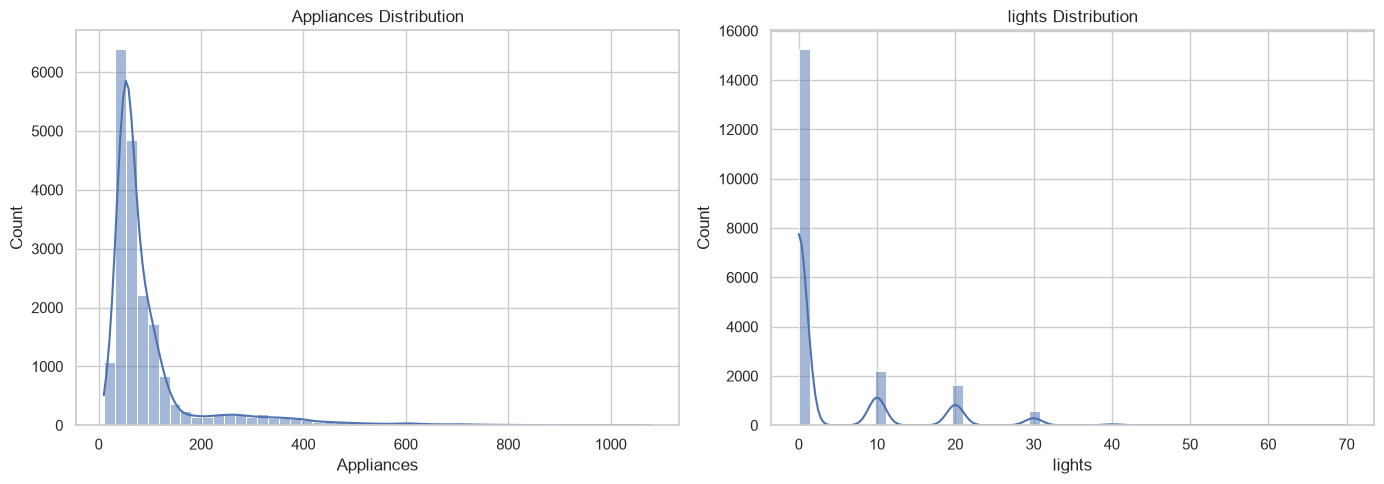

In [14]:
targets = ["Appliances", "lights"]

df[targets].describe().T

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, target in zip(axes, targets):
    sns.histplot(
        df[target],
        bins=50,
        kde=True,
        ax=ax
    )
    ax.set_title(f"{target} Distribution")
    ax.set_xlabel(target)

plt.tight_layout()
plt.show()

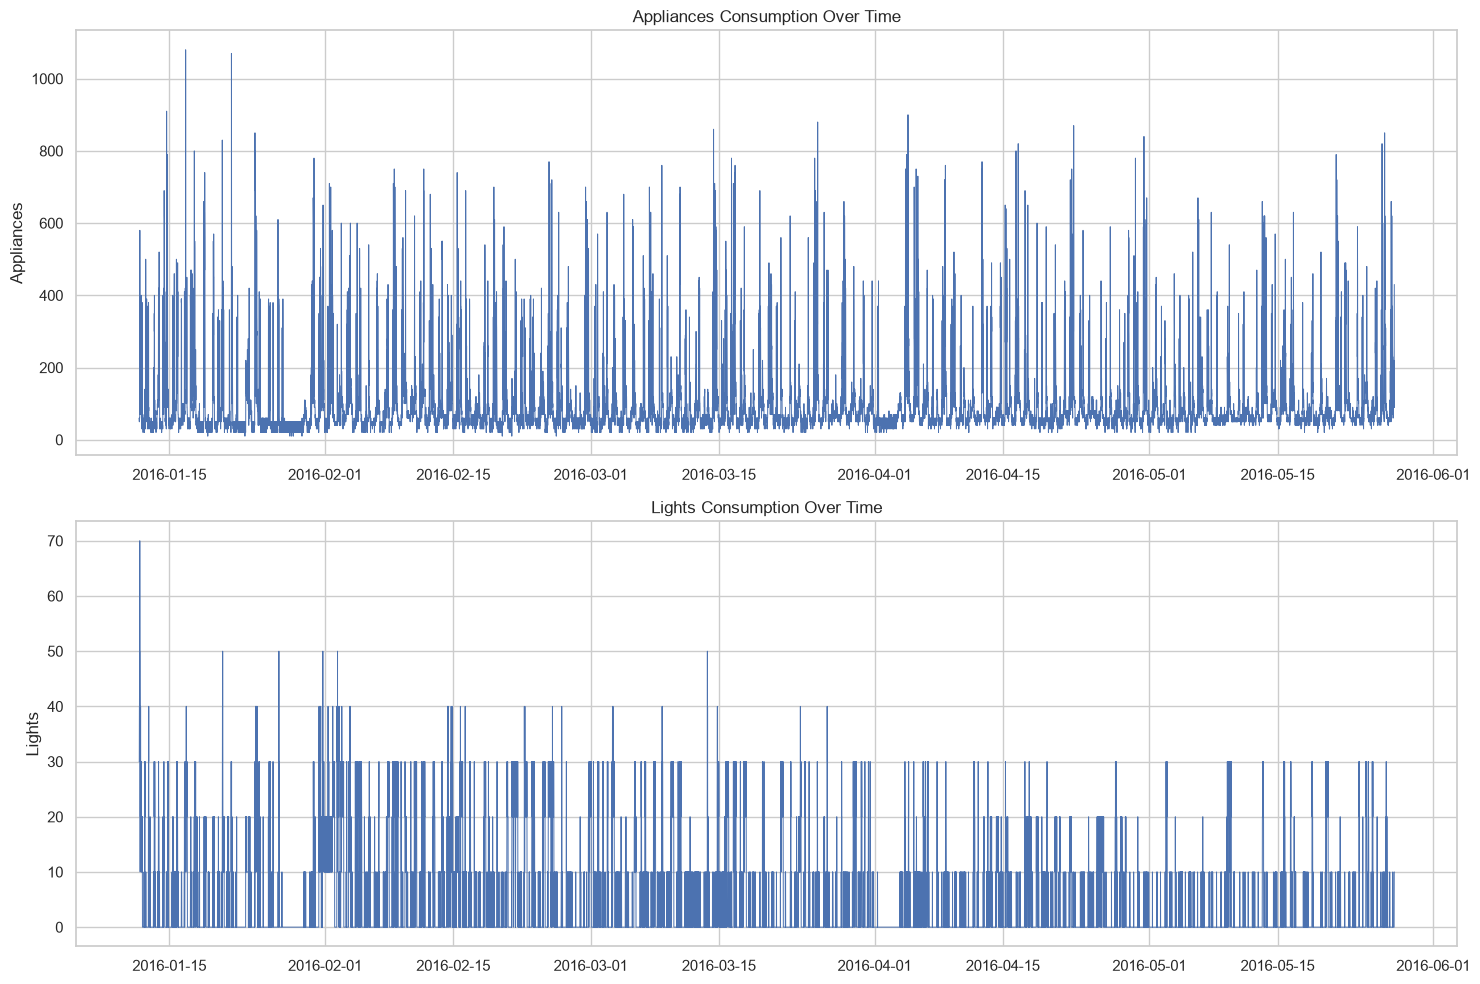

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

axes[0].plot(
    df["date"],
    df["Appliances"],
    linewidth=0.7
)

axes[0].set_title("Appliances Consumption Over Time")
axes[0].set_ylabel("Appliances")

axes[1].plot(
    df["date"],
    df["lights"],
    linewidth=0.7
)

axes[1].set_title("Lights Consumption Over Time")
axes[1].set_ylabel("Lights")

plt.tight_layout()
plt.show()

In [16]:
df["hour"] = df["date"].dt.hour
df["minute"] = df["date"].dt.minute
df["day_of_week"] = df["date"].dt.dayofweek
df["day_of_month"] = df["date"].dt.day
df["month"] = df["date"].dt.month
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)

df["is_weekend"] = (
    df["day_of_week"] >= 5
).astype(int)

df["is_weekday"] = (
    df["day_of_week"] < 5
).astype(int)

### Daily Usage Patterns

Energy consumption varies substantially throughout the day.

Appliance consumption is relatively low overnight and increases during daytime and evening periods, with the highest average consumption occurring around the evening.

Lighting consumption shows an even stronger relationship with time of day. Average lighting usage increases substantially during evening hours, consistent with scheduled or occupancy-related lighting behavior.

These patterns motivate the use of engineered temporal features such as hour, day of week, cyclical hour representations, and weekday/weekend indicators.

In [17]:
df["hour_sin"] = np.sin(
    2 * np.pi * df["hour"] / 24
)

df["hour_cos"] = np.cos(
    2 * np.pi * df["hour"] / 24
)

df["dow_sin"] = np.sin(
    2 * np.pi * df["day_of_week"] / 7
)

df["dow_cos"] = np.cos(
    2 * np.pi * df["day_of_week"] / 7
)

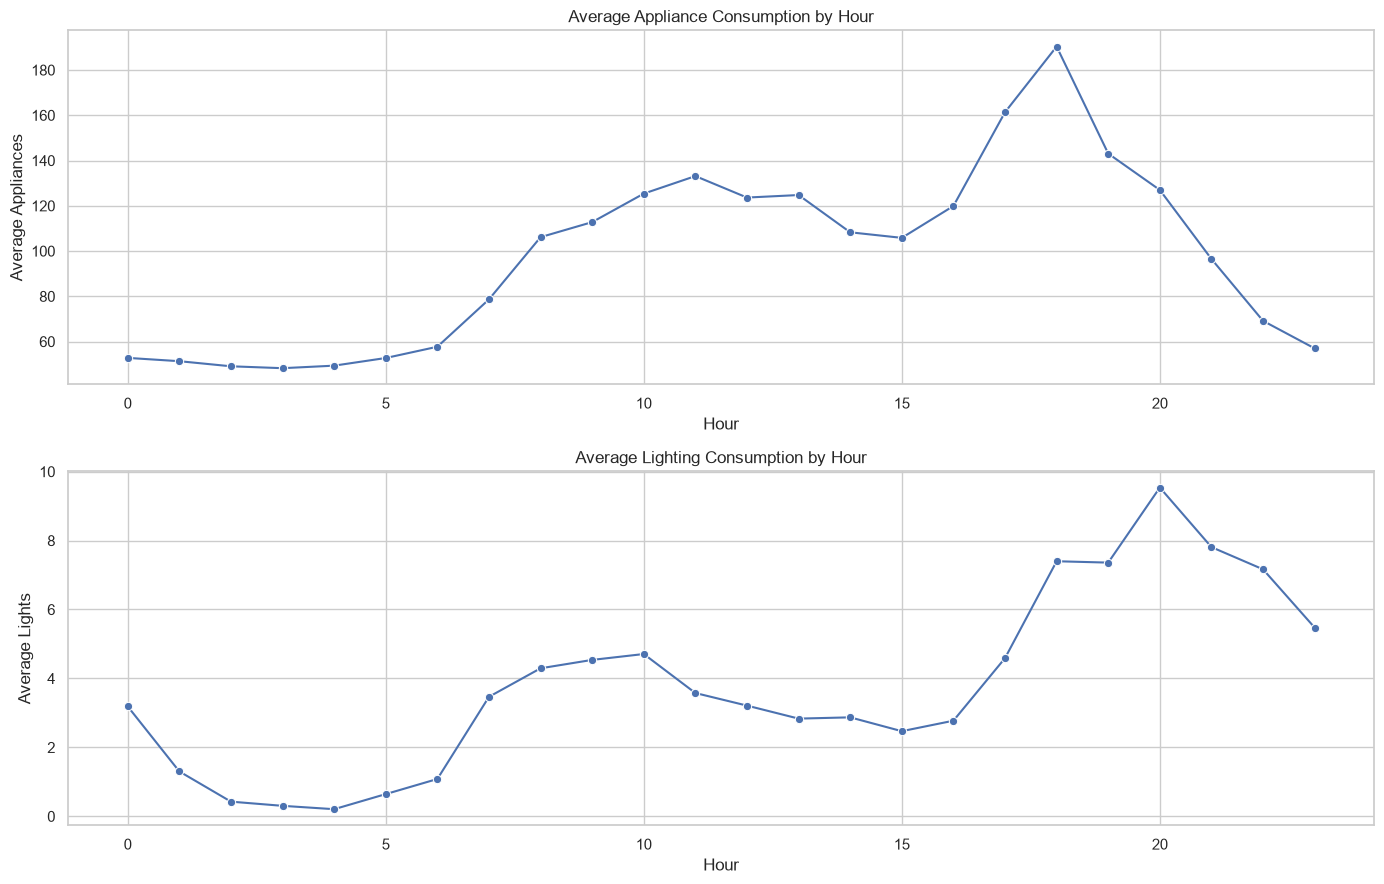

In [18]:
hourly_usage = (
    df.groupby("hour")[["Appliances", "lights"]]
      .mean()
      .reset_index()
)

hourly_usage

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

sns.lineplot(
    data=hourly_usage,
    x="hour",
    y="Appliances",
    marker="o",
    ax=axes[0]
)

axes[0].set_title("Average Appliance Consumption by Hour")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Average Appliances")

sns.lineplot(
    data=hourly_usage,
    x="hour",
    y="lights",
    marker="o",
    ax=axes[1]
)

axes[1].set_title("Average Lighting Consumption by Hour")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Average Lights")

plt.tight_layout()
plt.show()

### Weekday vs Weekend Patterns

Average Appliances consumption is slightly higher on weekends than weekdays, while lighting consumption is higher on weekdays.

This suggests that calendar structure provides useful information for both targets, although the effect differs between Appliances and lights.

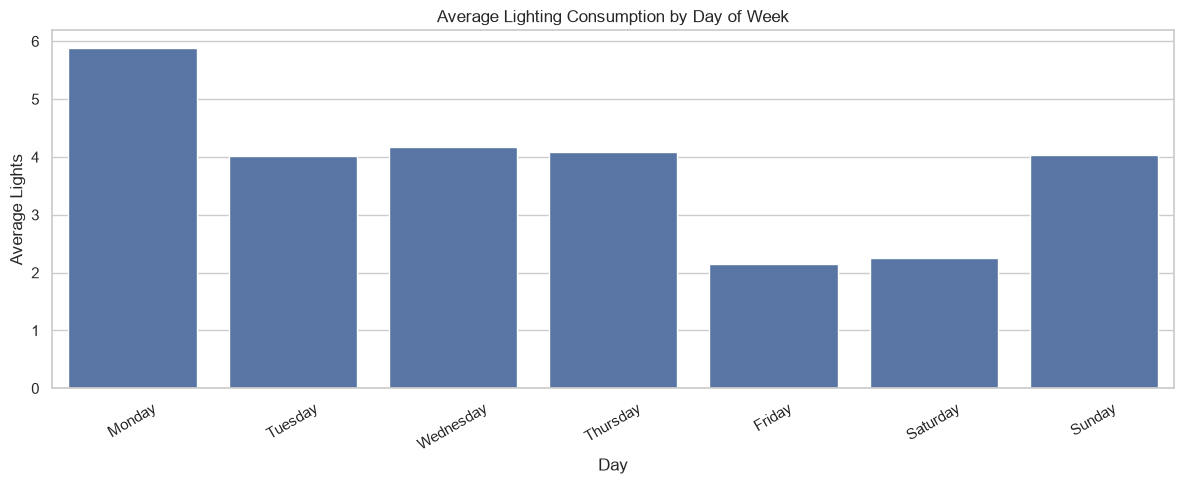

In [19]:
dow_usage = (
    df.groupby("day_of_week")[["Appliances", "lights"]]
      .mean()
      .reset_index()
)

dow_usage["day_name"] = dow_usage["day_of_week"].map({
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
})

dow_usage

plt.figure(figsize=(12, 5))

sns.barplot(
    data=dow_usage,
    x="day_name",
    y="lights"
)

plt.title("Average Lighting Consumption by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Lights")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## 4. Feature Engineering

The final feature set combines three types of information:

### Environmental variables

Indoor temperature and humidity measurements, together with outdoor weather variables, capture the physical conditions associated with energy consumption.

### Temporal variables

Calendar features include:

- Hour
- Minute
- Day of week
- Day of month
- Month
- Week of year
- Weekday/weekend indicators

Cyclical encodings using sine and cosine transformations were added for hour and day of week. These allow models to represent the circular nature of time, where for example 23:00 and 00:00 are close to one another.

### Aggregate environmental features

Additional features were created:

- Mean indoor temperature
- Mean indoor humidity
- Indoor-outdoor temperature difference

These provide compact representations of the overall indoor environment.

The variables `rv1` and `rv2` were initially excluded from the final feature set and subsequently tested separately for predictive usefulness.

In [20]:
temperature_cols = [
    f"T{i}" for i in range(1, 10)
]

humidity_cols = [
    f"RH_{i}" for i in range(1, 10)
]

existing_temperature_cols = [
    col for col in temperature_cols
    if col in df.columns
]

existing_humidity_cols = [
    col for col in humidity_cols
    if col in df.columns
]

print("Temperature columns:", existing_temperature_cols)
print("Humidity columns:", existing_humidity_cols)

df["mean_indoor_temperature"] = df[
    existing_temperature_cols
].mean(axis=1)

df["mean_indoor_humidity"] = df[
    existing_humidity_cols
].mean(axis=1)

if "T_out" in df.columns:
    df["indoor_outdoor_temp_diff"] = (
        df["mean_indoor_temperature"] - df["T_out"]
    )

Temperature columns: ['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9']
Humidity columns: ['RH_1', 'RH_2', 'RH_3', 'RH_4', 'RH_5', 'RH_6', 'RH_7', 'RH_8', 'RH_9']


In [21]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns

correlations = (
    df[numeric_cols]
    .corr()["Appliances"]
    .sort_values(ascending=False)
)

correlations

lights_correlations = (
    df[numeric_cols]
    .corr()["lights"]
    .sort_values(ascending=False)
)

lights_correlations

lights                      1.000000
hour                        0.255346
Appliances                  0.197278
RH_6                        0.153756
mean_indoor_humidity        0.146074
RH_5                        0.141233
RH_3                        0.131161
RH_4                        0.114936
RH_1                        0.106968
dow_cos                     0.097346
RH_out                      0.068543
dow_sin                     0.068450
Windspeed                   0.060281
indoor_outdoor_temp_diff    0.058317
is_weekday                  0.051404
RH_2                        0.050985
RH_7                        0.035069
Visibility                  0.020038
hour_cos                    0.018150
RH_8                        0.012915
rv2                         0.000521
rv1                         0.000521
minute                     -0.003348
T2                         -0.005622
RH_9                       -0.008766
T4                         -0.008859
Press_mm_hg                -0.010576
T

## Data Quality Assessment

The dataset contains 19,735 observations collected at 10-minute intervals between January 11, 2016 and May 27, 2016.

The initial quality assessment found:

- No missing values across the 29 variables.
- No duplicate rows.
- No duplicate timestamps.
- All consecutive observations occur exactly 10 minutes apart.
- No timestamp gaps were detected.
- The timestamp column was successfully parsed without invalid values.

Therefore, no missing-value imputation or timestamp-gap reconstruction was required. The dataset was sorted chronologically before feature engineering and model development.

In [22]:
negative_counts = (
    (df[numeric_cols] < 0)
    .sum()
    .sort_values(ascending=False)
)

negative_counts[negative_counts > 0]

df[["Appliances", "lights"]].describe(
    percentiles=[
        0.01,
        0.05,
        0.25,
        0.50,
        0.75,
        0.95,
        0.99
    ]
).T

print(
    "Appliances zero values:",
    (df["Appliances"] == 0).sum()
)

print(
    "Lights zero values:",
    (df["lights"] == 0).sum()
)

Appliances zero values: 0
Lights zero values: 15252


In [23]:
target_stats = df[["Appliances", "lights"]].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T

target_stats

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Appliances,19735.0,97.694958,102.524891,10.0,20.0,30.0,50.0,60.0,100.0,330.0,576.6,1080.0
lights,19735.0,3.801875,7.935988,0.0,0.0,0.0,0.0,0.0,0.0,20.0,30.0,70.0


In [24]:
feature_cols = [
    "T1", "T2", "T3", "T4", "T5", "T6", "T7", "T8", "T9",
    "RH_1", "RH_2", "RH_3", "RH_4", "RH_5", "RH_6", "RH_7", "RH_8", "RH_9",
    "T_out", "Press_mm_hg", "RH_out", "Windspeed", "Visibility", "Tdewpoint",
    "hour", "minute", "day_of_week", "day_of_month", "month", "week_of_year",
    "is_weekend", "is_weekday",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "mean_indoor_temperature",
    "mean_indoor_humidity",
    "indoor_outdoor_temp_diff"
]

X = df[feature_cols].copy()
y_appliances = df["Appliances"].copy()
y_lights = df["lights"].copy()

print("Number of features:", len(feature_cols))
print("X shape:", X.shape)

Number of features: 39
X shape: (19735, 39)


## 5. Time-Based Train / Validation / Test Split

Because this is a time-dependent energy forecasting problem, random train/test splitting was deliberately avoided.

Random splitting could allow observations from the future to influence model development and produce overly optimistic estimates of real-world forecasting performance.

The dataset was therefore divided chronologically:

| Split | Approx. Share | Period |
|---|---:|---|
| Train | 70% | Jan 11 – Apr 16 |
| Validation | 15% | Apr 16 – May 7 |
| Test | 15% | May 7 – May 27 |

The validation set was used for model selection and hyperparameter comparison. The test set was held out until the final model configurations had been selected.

In [25]:
n = len(df)

train_end = int(n * 0.70)
validation_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
validation_df = df.iloc[train_end:validation_end].copy()
test_df = df.iloc[validation_end:].copy()

print("Train:", train_df["date"].min(), "to", train_df["date"].max())
print("Validation:", validation_df["date"].min(), "to", validation_df["date"].max())
print("Test:", test_df["date"].min(), "to", test_df["date"].max())

print("\nRows:")
print("Train:", len(train_df))
print("Validation:", len(validation_df))
print("Test:", len(test_df))

Train: 2016-01-11 17:00:00 to 2016-04-16 15:10:00
Validation: 2016-04-16 15:20:00 to 2016-05-07 04:30:00
Test: 2016-05-07 04:40:00 to 2016-05-27 18:00:00

Rows:
Train: 13814
Validation: 2960
Test: 2961


In [26]:
X_train = train_df[feature_cols]
X_val = validation_df[feature_cols]
X_test = test_df[feature_cols]

y_app_train = train_df["Appliances"]
y_app_val = validation_df["Appliances"]
y_app_test = test_df["Appliances"]

y_light_train = train_df["lights"]
y_light_val = validation_df["lights"]
y_light_test = test_df["lights"]

In [27]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    denominator = np.abs(y_true) + np.abs(y_pred)

    return 100 * np.mean(
        np.where(
            denominator == 0,
            0,
            2 * np.abs(y_pred - y_true) / denominator
        )
    )

## 6. Baseline Models

A mean-prediction baseline was established for each target.

The baseline predicts the mean consumption observed in the training period for every validation observation.

This provides a simple benchmark against which more complex models can be evaluated. A machine learning model is only useful if it improves upon this naive benchmark on unseen chronological data.

In [28]:
app_baseline_value = y_app_train.mean()
light_baseline_value = y_light_train.mean()

app_baseline_pred = np.full(
    len(y_app_val),
    app_baseline_value
)

light_baseline_pred = np.full(
    len(y_light_val),
    light_baseline_value
)

baseline_results = pd.DataFrame({
    "Target": ["Appliances", "Lights"],
    "MAE": [
        mean_absolute_error(y_app_val, app_baseline_pred),
        mean_absolute_error(y_light_val, light_baseline_pred)
    ],
    "RMSE": [
        rmse(y_app_val, app_baseline_pred),
        rmse(y_light_val, light_baseline_pred)
    ],
    "sMAPE (%)": [
        smape(y_app_val, app_baseline_pred),
        smape(y_light_val, light_baseline_pred)
    ]
})

baseline_results

,Target,MAE,RMSE,sMAPE (%)
0,Appliances,53.967763,92.394288,50.680246
1,Lights,5.307954,5.994332,184.270082


In [29]:
from xgboost import XGBRegressor

app_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

app_model.fit(
    X_train,
    y_app_train,
    eval_set=[(X_train, y_app_train), (X_val, y_app_val)],
    verbose=False
)

app_val_pred = app_model.predict(X_val)

In [30]:
app_results = {
    "MAE": mean_absolute_error(y_app_val, app_val_pred),
    "RMSE": rmse(y_app_val, app_val_pred),
    "sMAPE (%)": smape(y_app_val, app_val_pred)
}

app_results

{'MAE': 74.71578979492188,
 'RMSE': np.float64(107.68011800002822),
 'sMAPE (%)': np.float64(57.13774335190909)}

In [31]:
light_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

light_model.fit(
    X_train,
    y_light_train,
    eval_set=[(X_train, y_light_train), (X_val, y_light_val)],
    verbose=False
)

light_val_pred = light_model.predict(X_val)

In [32]:
light_results = {
    "MAE": mean_absolute_error(y_light_val, light_val_pred),
    "RMSE": rmse(y_light_val, light_val_pred),
    "sMAPE (%)": smape(y_light_val, light_val_pred)
}

light_results

{'MAE': 5.149249076843262,
 'RMSE': np.float64(6.726601063333129),
 'sMAPE (%)': np.float64(182.90644366824708)}

In [33]:
comparison = pd.DataFrame({
    "Train Mean": [
        y_app_train.mean(),
        y_light_train.mean()
    ],
    "Validation Mean": [
        y_app_val.mean(),
        y_light_val.mean()
    ],
    "Train Median": [
        y_app_train.median(),
        y_light_train.median()
    ],
    "Validation Median": [
        y_app_val.median(),
        y_light_val.median()
    ],
    "Train Std": [
        y_app_train.std(),
        y_light_train.std()
    ],
    "Validation Std": [
        y_app_val.std(),
        y_light_val.std()
    ]
}, index=["Appliances", "Lights"])

comparison

,Train Mean,Validation Mean,Train Median,Validation Median,Train Std,Validation Std
Appliances,98.775156,93.422297,60.0,60.0,106.857292,92.254684
Lights,4.551904,2.121622,0.0,0.0,8.616680,5.480501


In [34]:
print("Appliances train mean:", y_app_train.mean())
print("Appliances validation mean:", y_app_val.mean())

print("Lights train mean:", y_light_train.mean())
print("Lights validation mean:", y_light_val.mean())

Appliances train mean: 98.7751556392066
Appliances validation mean: 93.42229729729729
Lights train mean: 4.55190386564355
Lights validation mean: 2.1216216216216215


## 7. Lights: Time vs Environment Analysis

A dedicated experiment was performed to determine whether lighting consumption is primarily associated with environmental conditions or temporal/schedule-related variables.

Three XGBoost configurations were compared:

1. Time features only
2. Environmental features only
3. Combined time and environmental features

### Result

The time-only model achieved a validation MAE of approximately **3.91**, compared with **5.82** for the environment-only model.

The combined model achieved an MAE of approximately **5.15**, which was also worse than the time-only model.

This provides strong evidence that lighting consumption in this dataset is more **schedule/time-driven than environment-driven**.

The finding is further supported by permutation importance, where `hour` was the dominant feature followed by `day_of_week`.

The interpretation should be treated as predictive rather than causal. Temporal variables may act as proxies for occupancy and household routines, which are not directly observed in the dataset.

In [35]:
time_features = [
    "hour",
    "minute",
    "day_of_week",
    "day_of_month",
    "month",
    "week_of_year",
    "is_weekend",
    "is_weekday",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos"
]

environment_features = [
    "T1", "T2", "T3", "T4", "T5", "T6", "T7", "T8", "T9",
    "RH_1", "RH_2", "RH_3", "RH_4", "RH_5", "RH_6", "RH_7", "RH_8", "RH_9",
    "T_out",
    "Press_mm_hg",
    "RH_out",
    "Windspeed",
    "Visibility",
    "Tdewpoint",
    "mean_indoor_temperature",
    "mean_indoor_humidity",
    "indoor_outdoor_temp_diff"
]

print("Time features:", len(time_features))
print("Environment features:", len(environment_features))

Time features: 12
Environment features: 27


In [36]:
light_time_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

light_time_model.fit(
    train_df[time_features],
    y_light_train,
    eval_set=[(validation_df[time_features], y_light_val)],
    verbose=False
)

light_time_pred = light_time_model.predict(validation_df[time_features])

In [37]:
light_env_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

light_env_model.fit(
    train_df[environment_features],
    y_light_train,
    eval_set=[(validation_df[environment_features], y_light_val)],
    verbose=False
)

light_env_pred = light_env_model.predict(validation_df[environment_features])

In [38]:
lights_driver_comparison = pd.DataFrame({
    "Model": [
        "Mean baseline",
        "Time-only XGBoost",
        "Environment-only XGBoost",
        "Combined XGBoost"
    ],
    "MAE": [
        mean_absolute_error(y_light_val, light_baseline_pred),
        mean_absolute_error(y_light_val, light_time_pred),
        mean_absolute_error(y_light_val, light_env_pred),
        mean_absolute_error(y_light_val, light_val_pred)
    ],
    "RMSE": [
        rmse(y_light_val, light_baseline_pred),
        rmse(y_light_val, light_time_pred),
        rmse(y_light_val, light_env_pred),
        rmse(y_light_val, light_val_pred)
    ],
    "sMAPE (%)": [
        smape(y_light_val, light_baseline_pred),
        smape(y_light_val, light_time_pred),
        smape(y_light_val, light_env_pred),
        smape(y_light_val, light_val_pred)
    ]
})

lights_driver_comparison

,Model,MAE,RMSE,sMAPE (%)
0,Mean baseline,5.307954,5.994332,184.270082
1,Time-only XGBoost,3.905594,6.185660,188.969780
2,Environment-only XGBoost,5.817163,7.218863,180.743387
3,Combined XGBoost,5.149249,6.726601,182.906444


In [39]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [40]:
app_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=10.0))
])

app_ridge.fit(X_train, y_app_train)

app_ridge_val_pred = app_ridge.predict(X_val)

In [41]:
app_ridge_results = {
    "MAE": mean_absolute_error(y_app_val, app_ridge_val_pred),
    "RMSE": rmse(y_app_val, app_ridge_val_pred),
    "sMAPE (%)": smape(y_app_val, app_ridge_val_pred)
}

app_ridge_results

{'MAE': 54.735645704815454,
 'RMSE': np.float64(88.0353920528264),
 'sMAPE (%)': np.float64(48.82104396905636)}

In [42]:
feature_cols_with_rv = feature_cols + ["rv1", "rv2"]

X_train_rv = train_df[feature_cols_with_rv]
X_val_rv = validation_df[feature_cols_with_rv]

In [43]:
app_ridge_rv = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=10.0))
])

app_ridge_rv.fit(X_train_rv, y_app_train)

app_ridge_rv_pred = app_ridge_rv.predict(X_val_rv)

In [44]:
rv_comparison = pd.DataFrame({
    "Model": [
        "Ridge without rv1/rv2",
        "Ridge with rv1/rv2"
    ],
    "MAE": [
        mean_absolute_error(y_app_val, app_ridge_val_pred),
        mean_absolute_error(y_app_val, app_ridge_rv_pred)
    ],
    "RMSE": [
        rmse(y_app_val, app_ridge_val_pred),
        rmse(y_app_val, app_ridge_rv_pred)
    ],
    "sMAPE (%)": [
        smape(y_app_val, app_ridge_val_pred),
        smape(y_app_val, app_ridge_rv_pred)
    ]
})

rv_comparison

,Model,MAE,RMSE,sMAPE (%)
0,Ridge without rv1/rv2,54.735646,88.035392,48.821044
1,Ridge with rv1/rv2,54.743568,88.039349,48.823174


In [45]:
model_comparison = pd.DataFrame([
    {
        "Target": "Appliances",
        "Model": "Mean baseline",
        "MAE": 53.967763,
        "RMSE": 92.394288,
        "sMAPE (%)": 50.680246
    },
    {
        "Target": "Appliances",
        "Model": "XGBoost",
        "MAE": 74.715790,
        "RMSE": 107.680120,
        "sMAPE (%)": 57.137740
    },
    {
        "Target": "Appliances",
        "Model": "Ridge (alpha=1000)",
        "MAE": 49.171416,
        "RMSE": 86.171117,
        "sMAPE (%)": 43.580781
    },
    {
        "Target": "lights",
        "Model": "Mean baseline",
        "MAE": 5.307954,
        "RMSE": 5.994332,
        "sMAPE (%)": 184.270082
    },
    {
        "Target": "lights",
        "Model": "Environment-only XGBoost",
        "MAE": 5.817163,
        "RMSE": 7.218863,
        "sMAPE (%)": 180.743387
    },
    {
        "Target": "lights",
        "Model": "Combined XGBoost",
        "MAE": 5.149249,
        "RMSE": 6.726601,
        "sMAPE (%)": 182.906444
    },
    {
        "Target": "lights",
        "Model": "Time-only XGBoost",
        "MAE": 3.905594,
        "RMSE": 6.185660,
        "sMAPE (%)": 188.969780
    }
])

model_comparison

,Target,Model,MAE,RMSE,sMAPE (%)
0,Appliances,Mean baseline,53.967763,92.394288,50.680246
1,Appliances,XGBoost,74.715790,107.680120,57.137740
2,Appliances,Ridge (alpha=1000),49.171416,86.171117,43.580781
3,lights,Mean baseline,5.307954,5.994332,184.270082
4,lights,Environment-only XGBoost,5.817163,7.218863,180.743387
5,lights,Combined XGBoost,5.149249,6.726601,182.906444
6,lights,Time-only XGBoost,3.905594,6.185660,188.969780


### Model Comparison Findings

For Appliances, the initial XGBoost configuration did not outperform the mean baseline on the chronological validation set. Ridge regression with strong regularization (`alpha=1000`) performed better and reduced both MAE and RMSE relative to the baseline.

For lights, the time-only XGBoost model produced the lowest validation MAE among the tested approaches. Environment-only modelling performed worse, while adding environmental variables to the time features did not improve performance.

This indicates that model complexity alone does not guarantee better forecasting performance. The selected models were therefore based on chronological validation performance rather than algorithmic complexity.

## 8. Key Driver Analysis

Permutation importance was used to assess which features contributed most to predictive performance on unseen validation data.

Permutation importance measures the deterioration in model performance when a feature's values are randomly shuffled. It therefore indicates predictive usefulness within the fitted model, rather than establishing causal relationships.

In [46]:
from sklearn.inspection import permutation_importance

app_perm = permutation_importance(
    app_ridge,
    X_val,
    y_app_val,
    scoring="neg_mean_absolute_error",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

app_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": app_perm.importances_mean
}).sort_values("Importance", ascending=False)

app_importance.head(15)

,Feature,Importance
10,RH_2,27.839797
1,T2,14.028834
33,hour_cos,11.777403
28,month,10.211233
23,Tdewpoint,9.260168
2,T3,8.007224
9,RH_1,6.054171
32,hour_sin,4.258302
11,RH_3,2.765354
8,T9,2.738410


### Appliances Drivers

The most influential variables for the final Ridge Appliances model include:

- `hour_cos`
- `T3`
- `RH_2`
- `hour_sin`
- `RH_1`
- `RH_3`
- `dow_sin`

This indicates that Appliances consumption contains both temporal and environmental predictive signals.

The importance of the cyclical hour features suggests that daily usage patterns are significant, while indoor temperature and humidity variables indicate that physical household conditions also contribute to prediction.

These results should not be interpreted as causal effects. They identify variables that are useful for prediction given the available data.

In [47]:
light_perm = permutation_importance(
    light_time_model,
    validation_df[time_features],
    y_light_val,
    scoring="neg_mean_absolute_error",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

light_importance = pd.DataFrame({
    "Feature": time_features,
    "Importance": light_perm.importances_mean
}).sort_values("Importance", ascending=False)

light_importance

,Feature,Importance
0,hour,0.171022
2,day_of_week,0.073256
1,minute,0.008314
11,dow_cos,0.002776
5,week_of_year,0.000000
4,month,0.000000
7,is_weekday,-0.001756
8,hour_sin,-0.016345
6,is_weekend,-0.025644
3,day_of_month,-0.026040


### Lights Drivers

For the time-only Lights model, `hour` is clearly the strongest feature, followed by `day_of_week`.

This reinforces the conclusion that lighting consumption is predominantly associated with daily and weekly schedules.

Several other temporal variables have very small or slightly negative permutation importance. This does not imply that these variables have a causal negative relationship with lighting demand. Instead, it can occur because of redundancy between correlated temporal features or noise introduced during permutation.

In [48]:
ridge_results = []

for alpha in [0.1, 1.0, 10.0, 100.0, 1000.0]:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=alpha))
    ])

    model.fit(X_train, y_app_train)
    pred = model.predict(X_val)

    ridge_results.append({
        "Alpha": alpha,
        "MAE": mean_absolute_error(y_app_val, pred),
        "RMSE": rmse(y_app_val, pred),
        "sMAPE (%)": smape(y_app_val, pred)
    })

ridge_results = pd.DataFrame(ridge_results)

ridge_results

,Alpha,MAE,RMSE,sMAPE (%)
0,0.1,52.651579,87.631058,47.331351
1,1.0,53.763469,87.948406,48.278949
2,10.0,54.735646,88.035392,48.821044
3,100.0,53.288875,87.108894,47.281272
4,1000.0,49.171416,86.171117,43.580781


In [49]:
rv_results = []

# Without rv1 / rv2
model_without_rv = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1000.0))
])

model_without_rv.fit(X_train, y_app_train)
pred_without_rv = model_without_rv.predict(X_val)

rv_results.append({
    "Model": "Ridge without rv1/rv2",
    "MAE": mean_absolute_error(y_app_val, pred_without_rv),
    "RMSE": rmse(y_app_val, pred_without_rv),
    "sMAPE (%)": smape(y_app_val, pred_without_rv)
})


# With rv1 / rv2
feature_cols_with_rv = feature_cols + ["rv1", "rv2"]

X_train_with_rv = train_df[feature_cols_with_rv]
X_val_with_rv = validation_df[feature_cols_with_rv]

model_with_rv = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1000.0))
])

model_with_rv.fit(X_train_with_rv, y_app_train)
pred_with_rv = model_with_rv.predict(X_val_with_rv)

rv_results.append({
    "Model": "Ridge with rv1/rv2",
    "MAE": mean_absolute_error(y_app_val, pred_with_rv),
    "RMSE": rmse(y_app_val, pred_with_rv),
    "sMAPE (%)": smape(y_app_val, pred_with_rv)
})

rv_results = pd.DataFrame(rv_results)

rv_results

,Model,MAE,RMSE,sMAPE (%)
0,Ridge without rv1/rv2,49.171416,86.171117,43.580781
1,Ridge with rv1/rv2,49.179467,86.172318,43.581547


## 9. Validation of `rv1` and `rv2`

The variables `rv1` and `rv2` were investigated separately rather than automatically assuming that every available column was useful.

Both variables showed negligible relationship with the target variables in exploratory analysis. Their inclusion was also evaluated through model comparison.

For the Appliances Ridge model, adding `rv1` and `rv2` produced slightly worse validation performance than the corresponding model without them.

Therefore, `rv1` and `rv2` were excluded from the final feature schema.

This decision reduces unnecessary model inputs and avoids retaining variables that do not demonstrate measurable predictive value.

In [50]:
final_app_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1000.0))
])

final_app_model.fit(X_train, y_app_train)

final_app_val_pred = final_app_model.predict(X_val)

In [51]:
final_app_val_results = {
    "MAE": mean_absolute_error(y_app_val, final_app_val_pred),
    "RMSE": rmse(y_app_val, final_app_val_pred),
    "sMAPE (%)": smape(y_app_val, final_app_val_pred)
}

final_app_val_results

{'MAE': 49.17141622990091,
 'RMSE': np.float64(86.17111733615664),
 'sMAPE (%)': np.float64(43.580781174483896)}

In [52]:
final_app_test_pred = final_app_model.predict(X_test)

In [53]:
final_light_test_pred = light_time_model.predict(
    test_df[time_features]
)

In [54]:
final_test_results = pd.DataFrame({
    "Target": ["Appliances", "Lights"],
    "MAE": [
        mean_absolute_error(y_app_test, final_app_test_pred),
        mean_absolute_error(y_light_test, final_light_test_pred)
    ],
    "RMSE": [
        rmse(y_app_test, final_app_test_pred),
        rmse(y_light_test, final_light_test_pred)
    ],
    "sMAPE (%)": [
        smape(y_app_test, final_app_test_pred),
        smape(y_light_test, final_light_test_pred)
    ]
})

final_test_results

,Target,MAE,RMSE,sMAPE (%)
0,Appliances,50.241873,84.307609,43.768477
1,Lights,3.935172,6.294020,191.172454


In [55]:
final_performance = pd.DataFrame({
    "Target": ["Appliances", "Lights"],
    "Validation MAE": [
        mean_absolute_error(y_app_val, final_app_val_pred),
        mean_absolute_error(y_light_val, light_time_pred)
    ],
    "Test MAE": [
        mean_absolute_error(y_app_test, final_app_test_pred),
        mean_absolute_error(y_light_test, final_light_test_pred)
    ],
    "Validation RMSE": [
        rmse(y_app_val, final_app_val_pred),
        rmse(y_light_val, light_time_pred)
    ],
    "Test RMSE": [
        rmse(y_app_test, final_app_test_pred),
        rmse(y_light_test, final_light_test_pred)
    ]
})

final_performance

,Target,Validation MAE,Test MAE,Validation RMSE,Test RMSE
0,Appliances,49.171416,50.241873,86.171117,84.307609
1,Lights,3.905594,3.935172,6.185660,6.294020


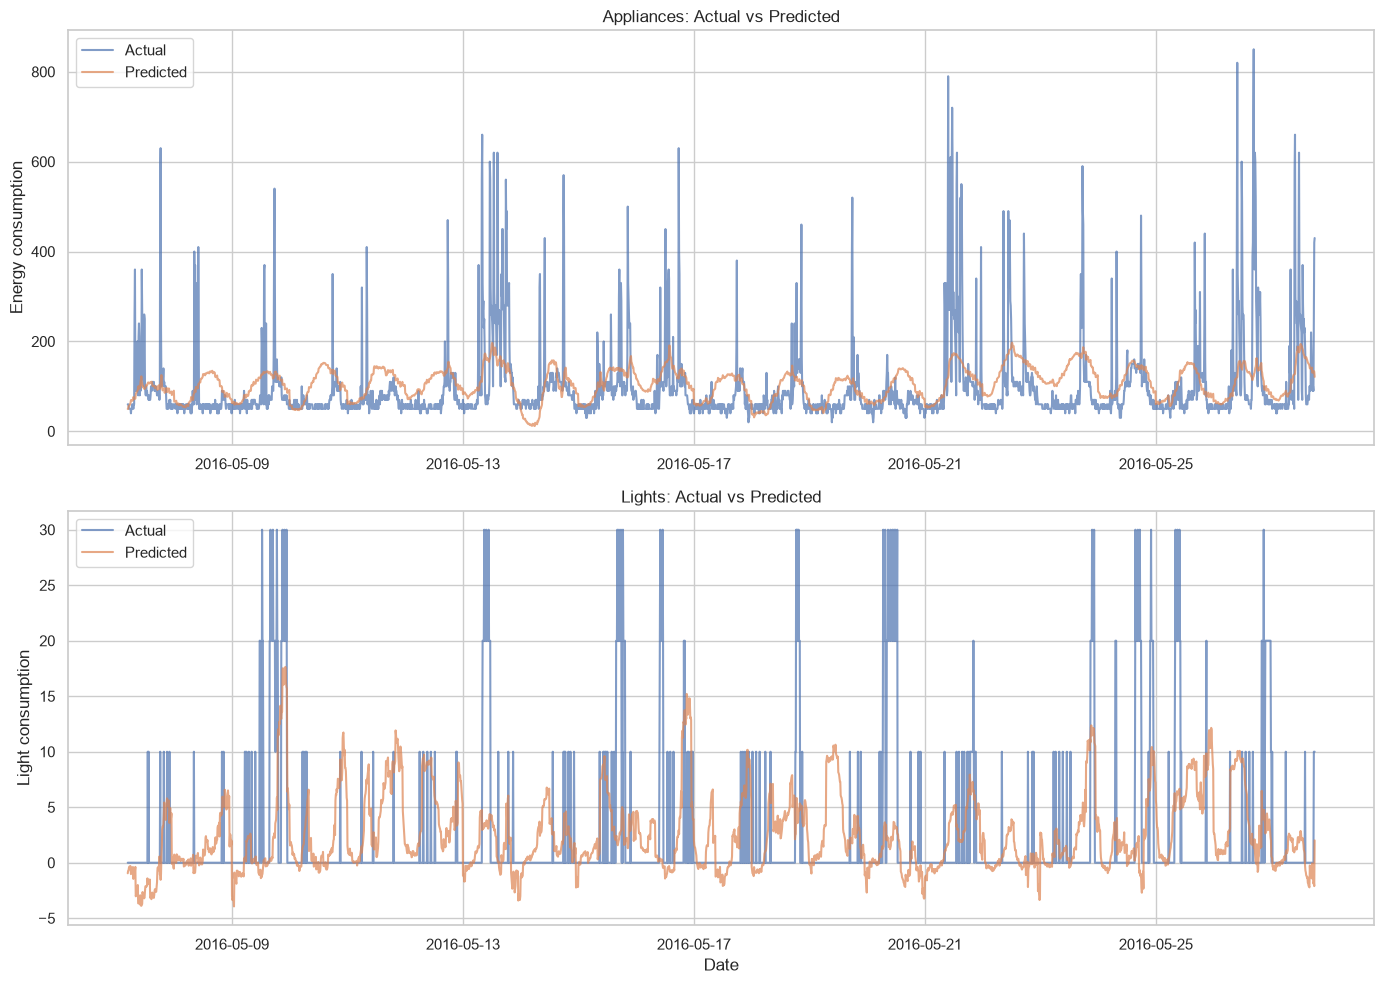

In [56]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Appliances
axes[0].plot(
    test_df["date"],
    y_app_test.values,
    label="Actual",
    alpha=0.7
)
axes[0].plot(
    test_df["date"],
    final_app_test_pred,
    label="Predicted",
    alpha=0.7
)
axes[0].set_title("Appliances: Actual vs Predicted")
axes[0].set_ylabel("Energy consumption")
axes[0].legend()

# Lights
axes[1].plot(
    test_df["date"],
    y_light_test.values,
    label="Actual",
    alpha=0.7
)
axes[1].plot(
    test_df["date"],
    final_light_test_pred,
    label="Predicted",
    alpha=0.7
)
axes[1].set_title("Lights: Actual vs Predicted")
axes[1].set_ylabel("Light consumption")
axes[1].set_xlabel("Date")
axes[1].legend()

plt.tight_layout()
plt.show()

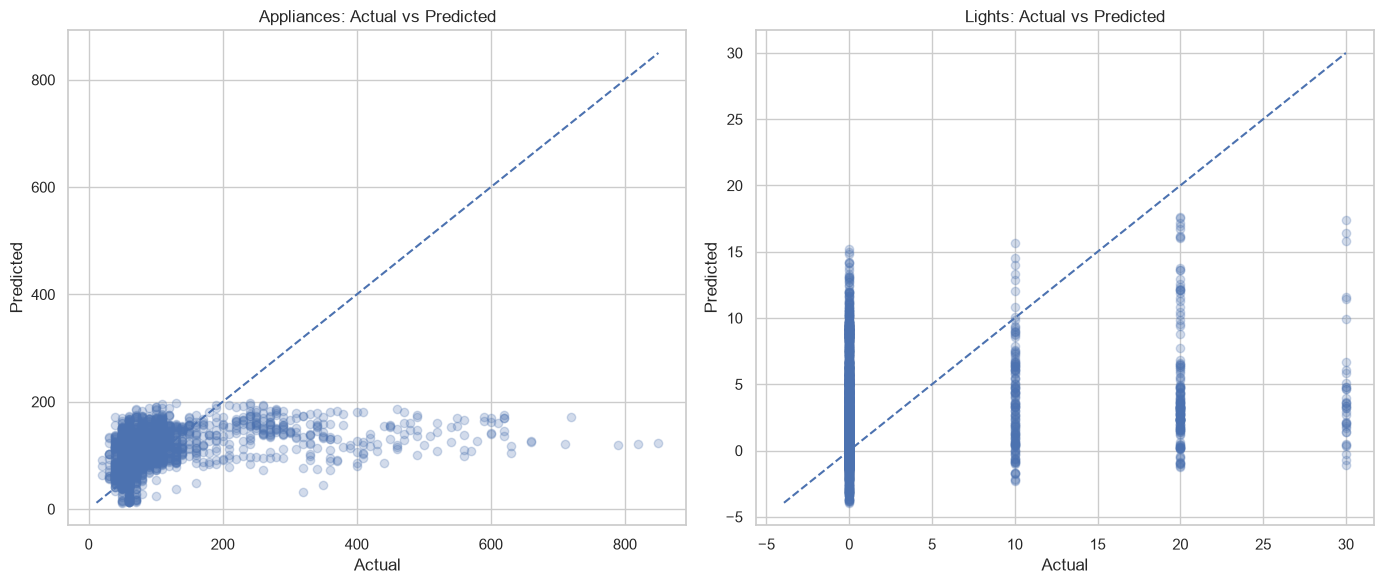

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Appliances
axes[0].scatter(
    y_app_test,
    final_app_test_pred,
    alpha=0.25
)

app_min = min(y_app_test.min(), final_app_test_pred.min())
app_max = max(y_app_test.max(), final_app_test_pred.max())

axes[0].plot(
    [app_min, app_max],
    [app_min, app_max],
    linestyle="--"
)

axes[0].set_title("Appliances: Actual vs Predicted")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")

# Lights
axes[1].scatter(
    y_light_test,
    final_light_test_pred,
    alpha=0.25
)

light_min = min(y_light_test.min(), final_light_test_pred.min())
light_max = max(y_light_test.max(), final_light_test_pred.max())

axes[1].plot(
    [light_min, light_max],
    [light_min, light_max],
    linestyle="--"
)

axes[1].set_title("Lights: Actual vs Predicted")
axes[1].set_xlabel("Actual")
axes[1].set_ylabel("Predicted")

plt.tight_layout()
plt.show()

## 10. Error Diagnostics

Error analysis was performed to understand where the final models perform well and where their predictions become unreliable.

Residuals are defined as:

`actual - predicted`

The analysis considers:

- Overall error
- Error by hour
- Largest individual prediction errors
- Model behavior during consumption spikes

In [58]:
app_residuals = y_app_test.values - final_app_test_pred
light_residuals = y_light_test.values - final_light_test_pred

test_results = test_df[["date"]].copy()

test_results["actual_Appliances"] = y_app_test.values
test_results["predicted_Appliances"] = final_app_test_pred
test_results["appliances_error"] = app_residuals

test_results["actual_lights"] = y_light_test.values
test_results["predicted_lights"] = final_light_test_pred
test_results["lights_error"] = light_residuals

test_results.head()

,date,actual_Appliances,predicted_Appliances,appliances_error,actual_lights,predicted_lights,lights_error
16774,2016-05-07 04:40:00,60,49.677190,10.322810,0,-0.950601,0.950601
16775,2016-05-07 04:50:00,60,49.904076,10.095924,0,-0.731876,0.731876
16776,2016-05-07 05:00:00,60,55.695507,4.304493,0,-0.705538,0.705538
16777,2016-05-07 05:10:00,50,56.827395,-6.827395,0,-0.458624,0.458624
16778,2016-05-07 05:20:00,50,57.287610,-7.287610,0,-0.352025,0.352025


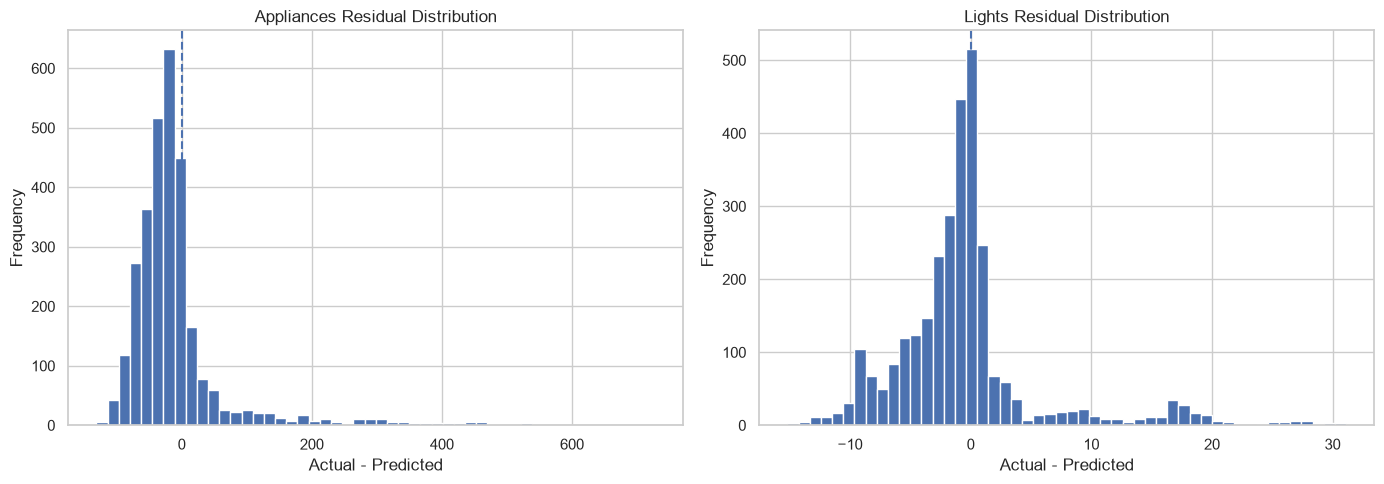

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(app_residuals, bins=50)
axes[0].axvline(0, linestyle="--")
axes[0].set_title("Appliances Residual Distribution")
axes[0].set_xlabel("Actual - Predicted")
axes[0].set_ylabel("Frequency")

axes[1].hist(light_residuals, bins=50)
axes[1].axvline(0, linestyle="--")
axes[1].set_title("Lights Residual Distribution")
axes[1].set_xlabel("Actual - Predicted")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [60]:
hour_errors = pd.DataFrame({
    "hour": test_df["hour"].values,
    "Appliances_MAE": np.abs(app_residuals),
    "Lights_MAE": np.abs(light_residuals)
})

hour_summary = (
    hour_errors
    .groupby("hour")
    .agg(
        Appliances_MAE=("Appliances_MAE", "mean"),
        Lights_MAE=("Lights_MAE", "mean")
    )
    .reset_index()
)

hour_summary

,hour,Appliances_MAE,Lights_MAE
0,0,19.073638,1.956932
1,1,17.132785,0.780242
2,2,16.991026,0.482533
3,3,18.648193,0.580696
4,4,20.486198,0.488650
5,5,24.283732,1.544666
6,6,28.898118,2.587765
7,7,41.026801,4.844605
8,8,65.486196,5.470077
9,9,70.785372,5.825337


### Error by Hour

Appliances prediction error varies substantially throughout the day.

The largest Appliances MAE occurs around the evening period, particularly around **17:00**, when consumption is also elevated. This suggests that the model has difficulty capturing high-demand events.

Lights errors are generally smaller during low-usage overnight periods and increase during periods where lighting demand is more variable.

This indicates that the final models capture broad temporal patterns but have more difficulty with abrupt household-level consumption changes.

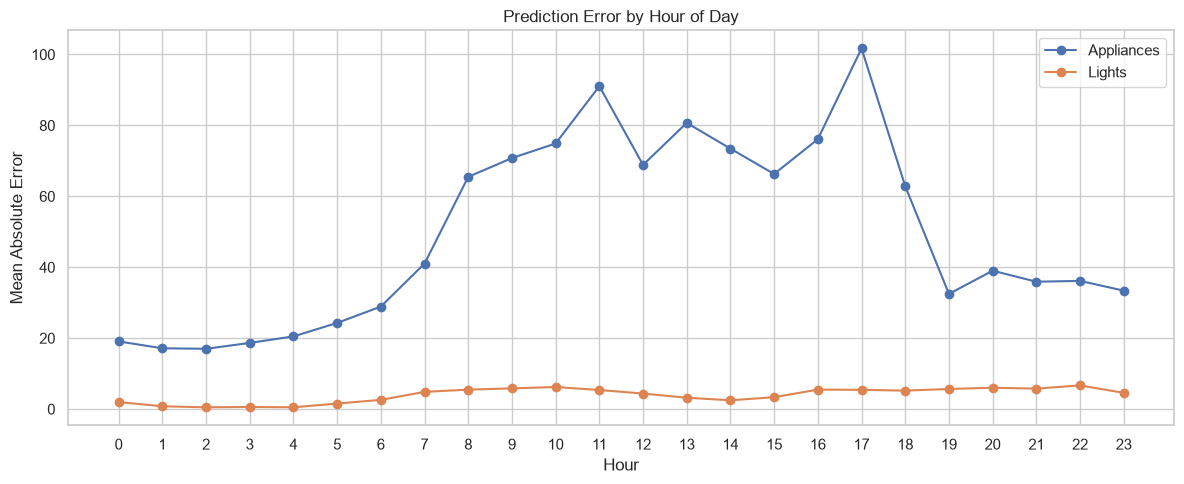

In [61]:
plt.figure(figsize=(12, 5))

plt.plot(
    hour_summary["hour"],
    hour_summary["Appliances_MAE"],
    marker="o",
    label="Appliances"
)

plt.plot(
    hour_summary["hour"],
    hour_summary["Lights_MAE"],
    marker="o",
    label="Lights"
)

plt.title("Prediction Error by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Mean Absolute Error")
plt.xticks(range(24))
plt.legend()
plt.tight_layout()
plt.show()

In [62]:
worst_app_errors = (
    test_results
    .assign(abs_error=lambda x: x["appliances_error"].abs())
    .sort_values("abs_error", ascending=False)
    [["date", "actual_Appliances", "predicted_Appliances", "appliances_error", "abs_error"]]
    .head(10)
)

worst_app_errors

,date,actual_Appliances,predicted_Appliances,appliances_error,abs_error
19582,2016-05-26 16:40:00,850,122.329265,727.670735,727.670735
19541,2016-05-26 09:50:00,820,120.327513,699.672487,699.672487
18820,2016-05-21 09:40:00,790,119.747238,670.252762,670.252762
19581,2016-05-26 16:30:00,710,121.512680,588.487320,588.487320
18830,2016-05-21 11:20:00,720,170.861780,549.138220,549.138220
17658,2016-05-13 08:00:00,660,125.608409,534.391591,534.391591
19685,2016-05-27 09:50:00,660,127.707758,532.292242,532.292242
16856,2016-05-07 18:20:00,630,105.217091,524.782909,524.782909
18148,2016-05-16 17:40:00,630,117.318209,512.681791,512.681791
19585,2016-05-26 17:10:00,620,136.347191,483.652809,483.652809


### Extreme Prediction Errors

The largest Appliances errors occur during high-consumption spikes. For example, several observations with actual consumption above 600–800 units are predicted much closer to the normal consumption range.

This indicates that the Ridge model is relatively conservative and tends to underestimate extreme peaks.

For lights, the largest errors occur when actual consumption suddenly reaches high values such as 30 units while the model predicts values close to zero. This is consistent with the zero-inflated and schedule-driven nature of the target: the model captures typical timing patterns but cannot observe sudden lighting events or occupancy changes from the available features.

These errors highlight an important limitation of the current feature set: the dataset does not directly provide occupancy, appliance state, or user-behaviour information.

In [63]:
worst_light_errors = (
    test_results
    .assign(abs_error=lambda x: x["lights_error"].abs())
    .sort_values("abs_error", ascending=False)
    [["date", "actual_lights", "predicted_lights", "lights_error", "abs_error"]]
    .head(10)
)

worst_light_errors

,date,actual_lights,predicted_lights,lights_error,abs_error
17109,2016-05-09 12:30:00,30,-1.114766,31.114766,31.114766
19298,2016-05-24 17:20:00,30,-0.691581,30.691581,30.691581
18108,2016-05-16 11:00:00,30,-0.269544,30.269544,30.269544
18102,2016-05-16 10:00:00,30,0.332680,29.667320,29.667320
17130,2016-05-09 16:00:00,30,0.390803,29.609197,29.609197
19287,2016-05-24 15:30:00,30,0.512836,29.487164,29.487164
18676,2016-05-20 09:40:00,30,1.379136,28.620864,28.620864
18658,2016-05-20 06:40:00,30,1.379559,28.620441,28.620441
17995,2016-05-15 16:10:00,30,1.728237,28.271763,28.271763
19293,2016-05-24 16:30:00,30,1.876755,28.123245,28.123245


In [64]:
kpis = pd.DataFrame({
    "Metric": [
        "Appliances mean",
        "Appliances median",
        "Appliances 95th percentile",
        "Appliances 99th percentile",
        "Appliances maximum",
        "Lights mean",
        "Lights median",
        "Lights 95th percentile",
        "Lights 99th percentile",
        "Lights maximum",
        "Lights zero share"
    ],
    "Value": [
        df["Appliances"].mean(),
        df["Appliances"].median(),
        df["Appliances"].quantile(0.95),
        df["Appliances"].quantile(0.99),
        df["Appliances"].max(),
        df["lights"].mean(),
        df["lights"].median(),
        df["lights"].quantile(0.95),
        df["lights"].quantile(0.99),
        df["lights"].max(),
        (df["lights"] == 0).mean()
    ]
})

kpis

,Metric,Value
0,Appliances mean,97.694958
1,Appliances median,60.000000
2,Appliances 95th percentile,330.000000
3,Appliances 99th percentile,576.600000
4,Appliances maximum,1080.000000
5,Lights mean,3.801875
6,Lights median,0.000000
7,Lights 95th percentile,20.000000
8,Lights 99th percentile,30.000000
9,Lights maximum,70.000000


In [65]:
hourly_usage = (
    df.groupby("hour")[["Appliances", "lights"]]
      .mean()
      .reset_index()
)

hourly_usage

,hour,Appliances,lights
0,0,52.785888,3.187348
1,1,51.326034,1.301703
2,2,49.075426,0.425791
3,3,48.236010,0.304136
4,4,49.355231,0.206813
5,5,52.737226,0.644769
6,6,57.712895,1.082725
7,7,78.649635,3.467153
8,8,106.143552,4.294404
9,9,112.785888,4.537713


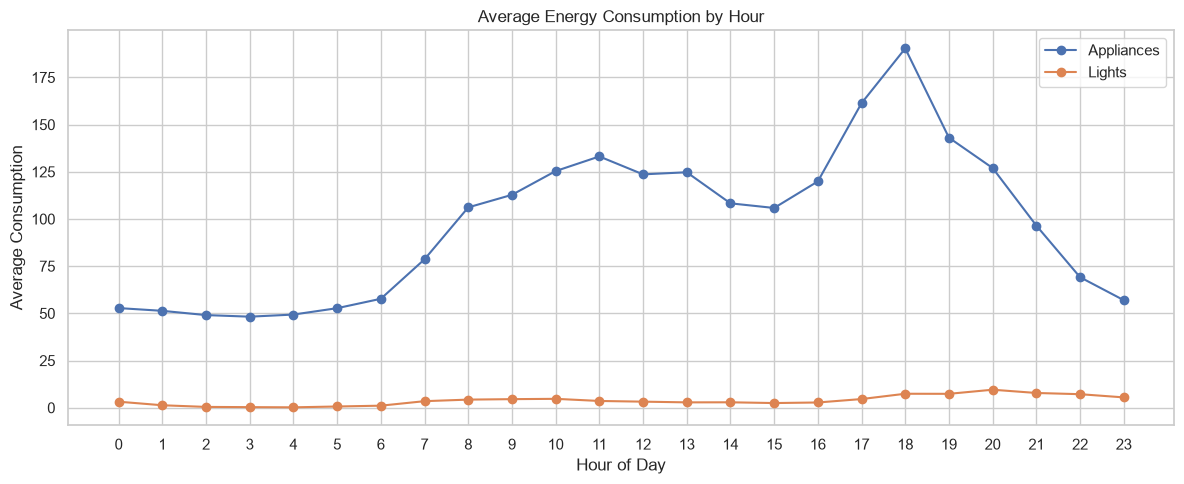

In [66]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_usage["hour"],
    hourly_usage["Appliances"],
    marker="o",
    label="Appliances"
)

plt.plot(
    hourly_usage["hour"],
    hourly_usage["lights"],
    marker="o",
    label="Lights"
)

plt.title("Average Energy Consumption by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Consumption")
plt.xticks(range(24))
plt.legend()
plt.tight_layout()
plt.show()

In [67]:
day_type_usage = (
    df.groupby("is_weekend")[["Appliances", "lights"]]
      .mean()
      .rename(index={0: "Weekday", 1: "Weekend"})
)

day_type_usage

,Appliances,lights
is_weekend,,
Weekday,96.587674,4.054547
Weekend,100.581140,3.143275


In [68]:
app_importance.head(10)

,Feature,Importance
10,RH_2,27.839797
1,T2,14.028834
33,hour_cos,11.777403
28,month,10.211233
23,Tdewpoint,9.260168
2,T3,8.007224
9,RH_1,6.054171
32,hour_sin,4.258302
11,RH_3,2.765354
8,T9,2.738410


In [69]:
light_importance.head(10)

,Feature,Importance
0,hour,0.171022
2,day_of_week,0.073256
1,minute,0.008314
11,dow_cos,0.002776
5,week_of_year,0.000000
4,month,0.000000
7,is_weekday,-0.001756
8,hour_sin,-0.016345
6,is_weekend,-0.025644
3,day_of_month,-0.026040


In [70]:
final_light_test_pred_clipped = np.maximum(final_light_test_pred, 0)

light_clipped_results = {
    "MAE": mean_absolute_error(y_light_test, final_light_test_pred_clipped),
    "RMSE": rmse(y_light_test, final_light_test_pred_clipped),
    "sMAPE (%)": smape(y_light_test, final_light_test_pred_clipped)
}

light_clipped_results

{'MAE': 3.7132418155670166,
 'RMSE': np.float64(6.2383457627182395),
 'sMAPE (%)': np.float64(145.98501768112408)}

In [71]:
pd.DataFrame({
    "Metric": ["MAE", "RMSE", "sMAPE (%)"],
    "Original": [
        mean_absolute_error(y_light_test, final_light_test_pred),
        rmse(y_light_test, final_light_test_pred),
        smape(y_light_test, final_light_test_pred)
    ],
    "Clipped at zero": [
        mean_absolute_error(y_light_test, final_light_test_pred_clipped),
        rmse(y_light_test, final_light_test_pred_clipped),
        smape(y_light_test, final_light_test_pred_clipped)
    ]
})

,Metric,Original,Clipped at zero
0,MAE,3.935172,3.713242
1,RMSE,6.294020,6.238346
2,sMAPE (%),191.172454,145.985018


In [72]:
final_app_perm = permutation_importance(
    final_app_model,
    X_val,
    y_app_val,
    scoring="neg_mean_absolute_error",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

final_app_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": final_app_perm.importances_mean
}).sort_values(
    "Importance",
    ascending=False
)

final_app_importance.head(10)

,Feature,Importance
33,hour_cos,6.821510
2,T3,5.246845
10,RH_2,4.006005
32,hour_sin,3.836585
9,RH_1,1.793613
11,RH_3,1.651228
34,dow_sin,1.484623
7,T8,1.121090
20,RH_out,1.109821
1,T2,0.929373


In [73]:
train_val_df = pd.concat(
    [train_df, validation_df],
    axis=0
).reset_index(drop=True)

X_train_val = train_val_df[feature_cols]

y_app_train_val = train_val_df["Appliances"]
y_light_train_val = train_val_df["lights"]

print("Training rows:", len(train_val_df))
print("Start:", train_val_df["date"].min())
print("End:", train_val_df["date"].max())

Training rows: 16774
Start: 2016-01-11 17:00:00
End: 2016-05-07 04:30:00


In [74]:
final_app_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1000.0))
])

final_app_model.fit(
    X_train_val,
    y_app_train_val
)

final_app_test_pred = final_app_model.predict(X_test)

## 11. Final Model Selection

The final models were selected based on chronological validation performance and the observed characteristics of each target.

| Target | Selected Model | Feature Set | Rationale |
|---|---|---|---|
| Appliances | Ridge Regression, α = 1000 | Environmental + temporal | Best validation performance among tested Appliances models |
| lights | XGBoost | Time features only | Lowest validation MAE and strong evidence of schedule-driven demand |

After model selection, the training and validation datasets were combined and each final model was refitted before generating predictions for the untouched test period.

The test set therefore represents genuinely unseen future observations relative to model development.

In [75]:
final_light_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

final_light_model.fit(
    train_val_df[time_features],
    y_light_train_val,
    verbose=False
)

final_light_test_pred = final_light_model.predict(
    test_df[time_features]
)

# Energy consumption cannot be negative
final_light_test_pred = np.maximum(
    final_light_test_pred,
    0
)

In [76]:
final_results = pd.DataFrame({
    "Target": ["Appliances", "Lights"],
    "Model": [
        "Ridge (alpha=1000)",
        "XGBoost (time-only)"
    ],
    "MAE": [
        mean_absolute_error(y_app_test, final_app_test_pred),
        mean_absolute_error(y_light_test, final_light_test_pred)
    ],
    "RMSE": [
        rmse(y_app_test, final_app_test_pred),
        rmse(y_light_test, final_light_test_pred)
    ],
    "sMAPE (%)": [
        smape(y_app_test, final_app_test_pred),
        smape(y_light_test, final_light_test_pred)
    ]
})

final_results

,Target,Model,MAE,RMSE,sMAPE (%)
0,Appliances,Ridge (alpha=1000),47.908198,83.712553,41.988612
1,Lights,XGBoost (time-only),3.219342,5.922704,146.949964


## 12. Final Test Performance

The final models were evaluated on the held-out chronological test period after refitting on the combined training and validation observations.

| Target | Model | MAE | RMSE | sMAPE |
|---|---|---:|---:|---:|
| Appliances | Ridge (α = 1000) | **47.91** | **83.71** | **41.99%** |
| lights | XGBoost (time-only) | **3.22** | **5.92** | **146.95%** |

The Appliances model achieves a test MAE of approximately 47.91 consumption units.

The Lights model achieves a test MAE of approximately 3.22 units.

The high sMAPE for lights should not be interpreted as evidence of poor predictive performance in isolation. Because approximately 77.3% of the observations have zero actual lighting consumption, percentage-based errors become unstable when actual and predicted values are close to zero. MAE and RMSE are therefore the primary metrics used to assess the Lights model.

In [77]:
import joblib

joblib.dump(
    final_app_model,
    MODEL_PATH / "appliances_model.joblib"
)

joblib.dump(
    final_light_model,
    MODEL_PATH / "lights_model.joblib"
)

joblib.dump(
    {
        "all_features": feature_cols,
        "time_features": time_features,
        "environment_features": environment_features
    },
    MODEL_PATH / "feature_schema.joblib"
)

print("Models saved successfully.")

Models saved successfully.


In [78]:
test_predictions = test_df[["date"]].copy()

test_predictions["actual_Appliances"] = y_app_test.values
test_predictions["predicted_Appliances"] = final_app_test_pred

test_predictions["actual_lights"] = y_light_test.values
test_predictions["predicted_lights"] = final_light_test_pred

test_predictions.head()

,date,actual_Appliances,predicted_Appliances,actual_lights,predicted_lights
16774,2016-05-07 04:40:00,60,54.585916,0,0.0
16775,2016-05-07 04:50:00,60,55.203555,0,0.0
16776,2016-05-07 05:00:00,60,59.975109,0,0.0
16777,2016-05-07 05:10:00,50,61.363246,0,0.0
16778,2016-05-07 05:20:00,50,61.870057,0,0.0


In [79]:
csv_path = OUTPUT_PATH / "test_predictions.csv"

test_predictions.to_csv(
    csv_path,
    index=False
)

print(f"Saved: {csv_path}")

Saved: C:\Users\precy\Documents\R1 - Gajulapalle Sai Preetham\Gajulapalle Sai Preetham\UP-Analytics-2026-Assessment-Preetham\outputs\test_predictions.csv


In [80]:
excel_path = OUTPUT_PATH / "test_predictions.xlsx"

test_predictions.to_excel(
    excel_path,
    index=False
)

print(f"Saved: {excel_path}")

Saved: C:\Users\precy\Documents\R1 - Gajulapalle Sai Preetham\Gajulapalle Sai Preetham\UP-Analytics-2026-Assessment-Preetham\outputs\test_predictions.xlsx


In [81]:
import os

print("Models:")
print(os.listdir(MODEL_PATH))

print("\nOutputs:")
print(os.listdir(OUTPUT_PATH))

Models:
['appliances_model.joblib', 'feature_schema.joblib', 'lights_model.joblib']

Outputs:
['test_predictions.csv', 'test_predictions.xlsx']


In [82]:
print("Number of features:", len(feature_cols))
print(feature_cols)

Number of features: 39
['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'RH_1', 'RH_2', 'RH_3', 'RH_4', 'RH_5', 'RH_6', 'RH_7', 'RH_8', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'hour', 'minute', 'day_of_week', 'day_of_month', 'month', 'week_of_year', 'is_weekend', 'is_weekday', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'mean_indoor_temperature', 'mean_indoor_humidity', 'indoor_outdoor_temp_diff']


In [83]:
print("Number of features:", len(feature_cols))
print(feature_cols)

Number of features: 39
['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'RH_1', 'RH_2', 'RH_3', 'RH_4', 'RH_5', 'RH_6', 'RH_7', 'RH_8', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'hour', 'minute', 'day_of_week', 'day_of_month', 'month', 'week_of_year', 'is_weekend', 'is_weekday', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'mean_indoor_temperature', 'mean_indoor_humidity', 'indoor_outdoor_temp_diff']


In [84]:
import json

sample_payload = {
    "features": {
        feature: float(test_df.iloc[0][feature])
        for feature in feature_cols
    }
}

print(json.dumps(sample_payload, indent=2))

{
  "features": {
    "T1": 23.7,
    "T2": 21.6,
    "T3": 24.533333333333296,
    "T4": 23.6,
    "T5": 21.1,
    "T6": 10.814,
    "T7": 22.79,
    "T8": 23.7,
    "T9": 21.79,
    "RH_1": 38.0,
    "RH_2": 39.2,
    "RH_3": 38.2,
    "RH_4": 36.6266666666667,
    "RH_5": 48.0,
    "RH_6": 23.034,
    "RH_7": 34.0385714285714,
    "RH_8": 43.0,
    "RH_9": 43.4,
    "T_out": 11.9666666666667,
    "Press_mm_hg": 751.966666666667,
    "RH_out": 64.3333333333333,
    "Windspeed": 1.0,
    "Visibility": 40.0,
    "Tdewpoint": 5.3333333333333295,
    "hour": 4.0,
    "minute": 40.0,
    "day_of_week": 5.0,
    "day_of_month": 7.0,
    "month": 5.0,
    "week_of_year": 18.0,
    "is_weekend": 1.0,
    "is_weekday": 0.0,
    "hour_sin": 0.8660254037844386,
    "hour_cos": 0.5000000000000001,
    "dow_sin": -0.9749279121818236,
    "dow_cos": -0.2225209339563146,
    "mean_indoor_temperature": 21.514148148148138,
    "mean_indoor_humidity": 38.166582010582005,
    "indoor_outdoor_temp_diff"

## 13. Business Insights and Recommendations

The analysis provides several actionable insights for a smart-home energy management system.

### 1. Use different forecasting strategies for Appliances and lights

The two targets have materially different predictive structures.

Appliance consumption benefits from both environmental and temporal information, while lighting consumption is much more strongly associated with time of day and day of week.

A production system should therefore avoid assuming that one modelling strategy is optimal for all energy categories.

### 2. Prioritize peak-demand monitoring for Appliances

Appliance consumption reaches substantially higher values than its typical operating level, with a maximum observed value of 1080.

The final model tends to underestimate these extreme events. A production energy-management system could therefore supplement point predictions with a peak-demand alerting layer.

This would allow the system to distinguish between expected baseline demand and potentially important high-consumption events.

### 3. Use temporal schedules for lighting optimization

Because `hour` and `day_of_week` are the strongest predictors of lighting demand, schedule-based controls could be particularly effective.

Potential applications include:

- Automated lighting schedules
- Detection of unusually high lighting usage
- Recommendations to reduce lighting during historically low-demand periods
- Occupancy-aware lighting controls when occupancy data becomes available

### 4. Collect occupancy and device-state information

The largest prediction errors are associated with abrupt consumption changes that cannot be explained using the available environmental and temporal variables.

Adding information such as:

- Occupancy
- Individual appliance states
- Room-level activity
- Motion sensors
- Smart-plug measurements

could improve the model's ability to detect short-lived demand spikes.

### 5. Use model uncertainty for operational decisions

For deployment, a point prediction alone may not be sufficient for peak-demand management.

A future version could provide prediction intervals or quantile forecasts so that the system can identify periods where unusually high consumption is likely.

## 14. Limitations and Future Improvements

Several limitations should be considered when interpreting the results.

1. The dataset covers approximately four and a half months, limiting the ability to learn longer-term seasonal patterns.
2. Occupancy and individual appliance-state information are not directly available.
3. Appliances contains substantial consumption spikes that the final Ridge model does not fully capture.
4. Lights is highly zero-inflated, making sMAPE unsuitable as the primary evaluation metric.
5. Model performance may change when applied to households with different routines, climates, or appliance configurations.
6. The current analysis focuses on point prediction rather than probabilistic forecasting.

Potential future improvements include:

- Occupancy-aware features
- Appliance-level sensor data
- Lagged and rolling consumption features where the deployment setup permits them
- Specialized models for zero-inflated lighting demand
- Tree-based or quantile models specifically targeting appliance peaks
- Longer historical datasets covering multiple seasons

## 15. Conclusion

This analysis developed and evaluated separate machine learning models for Appliances and lights energy consumption using a strictly chronological validation framework.

The key findings are:

- The dataset is structurally clean, with no missing observations, duplicates, or timestamp gaps.
- Appliances consumption has both temporal and environmental predictive signals and contains difficult high-demand spikes.
- Lights consumption is strongly schedule-driven, with `hour` and `day_of_week` providing substantially more predictive information than environmental variables.
- `rv1` and `rv2` do not provide meaningful predictive value and were excluded from the final models.
- Ridge Regression with α = 1000 was selected for Appliances.
- Time-only XGBoost was selected for lights.
- Final test MAE was **47.91 for Appliances** and **3.22 for lights**.

The resulting models provide useful short-term predictions while also highlighting where additional sensor information, particularly occupancy and appliance-state data, would be most valuable for improving real-world energy management.